# 06 — End-of-Day Survey (Issue 8)

Demonstrates the end-of-day survey re-administration after political broadcasts:
1. Load data, create agents, run baseline survey
2. Run P-A broadcast to accumulate reflections
3. Administer end-of-day survey with reflection-aware context
4. Analyse opinion shifts

**Covers:** Issue 8 (End-of-Day Survey)
**Depends on:** Issues 3, 6, 7
**Note:** Clamping is not implemented — see Issue 8 PR comment for rationale.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys, random
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../src')))

from cag.io.survey import load
from cag.abm.agent import SurveyedCitizen, PoliticalAgent
from cag.abm.environment import SurveyedNation
from cag.abm.attributes.opinion import ClimatePolicyID, SURVEY_QUESTIONS, RESPONSE_LABELS

from gabm.abm.attributes.gender import GenderMap, GenderID
from gabm.abm.attributes.politics import PoliticsID
from gabm.abm.democracy.election import ElectionID
from cag.abm.attributes.region import UKRegionMap, RegionID
from cag.abm.attributes.education import SurveyEducationMap, EducationID
from cag.abm.attributes.ethnicity import SurveyEthnicityMap, EthnicityID
from cag.abm.attributes.income import SurveyIncomeMap, IncomeID
from cag.abm.attributes.politics import SurveyPoliticsMap
from cag.abm.attributes.family import SurveyFamilyMap, FamilyID
from cag.abm.democracy.elections.ukge2019 import UKGE2019VoteMap, UKGE2019VoteID
from cag.abm.democracy.elections.brexit import BrexitVoteMap, BrexitVoteID
from cag.abm.attributes.narratives import (
    SelftranscMap, SelfenhMap, OpennessMap, ConformTradMap, SDOMap, EDOMap, RWAMap,
    rescale_1_6, rescale_1_7,
)
import pandas as pd
import matplotlib.pyplot as plt
import logging
logging.basicConfig(level=logging.INFO, format="%(message)s")

print("Imports OK")

Imports OK


## 1. Load Data & Build Environment

In [2]:
MAX_DEMO = 2
random.seed(42)
year = 2026

UKGE2019_ELECTION_ID = ElectionID(0)
BREXIT_REFERENDUM_ID = ElectionID(1)

nation = SurveyedNation(
    year=year, place="UK",
    gender_map=GenderMap(),
    region_map=UKRegionMap(),
    education_map=SurveyEducationMap(),
    ethnicity_map=SurveyEthnicityMap(),
    income_map=SurveyIncomeMap(),
    politics_map=SurveyPoliticsMap(),
    family_map=SurveyFamilyMap(),
    ukge2019_vote_map=UKGE2019VoteMap(UKGE2019_ELECTION_ID),
    brexit_vote_map=BrexitVoteMap(BREXIT_REFERENDUM_ID),
    selftransc_map=SelftranscMap,
    selfenh_map=SelfenhMap,
    openness_map=OpennessMap,
    conformtrad_map=ConformTradMap,
    sdo_map=SDOMap,
    edo_map=EDOMap,
    rwa_map=RWAMap,
)

data = load("../data/yougov_survey_data/YouGovProcessedData_train.csv")

for i in range(min(MAX_DEMO, len(data))):
    print(i)
    row = data.iloc[i]
    sc = SurveyedCitizen(
        agent_id=row.get('ID', None), environment=nation,
        year_of_birth=year - int(row.get('age', 0)),
        gender_id=GenderID.MALE if int(row.get('male_dummy', 0)) == 1 else GenderID.FEMALE,
        region_id=RegionID(int(row.get('tprofile_GOR', 0))),
        education_id=EducationID(int(row.get('profile_education_level', 0))),
        income_id=IncomeID(int(row.get('tprofile_gross_household', 0))),
        ethnicity_id=EthnicityID(int(row.get('ethnicity_R', 0))),
        family_id=FamilyID.PARENT if int(row.get('parent_dummy', 0)) == 1 else FamilyID.NOT_PARENT,
        ukge2019_vote_id=UKGE2019VoteID(int(row.get('Vote2019R', 0))),
        brexit_vote_id=BrexitVoteID(int(row.get('pastvote_EURef', 0))),
        politics_id=PoliticsID(int(row.get('Political_Left_Right', 0))),
        selftransc_id=rescale_1_6(int(row.get('Selftransc_Val', 0))),
        selfenh_id=rescale_1_6(int(row.get('Selfenh_Values', 0))),
        openness_id=rescale_1_6(int(row.get('Openness', 0))),
        conformtrad_id=rescale_1_6(int(row.get('ConformTrad', 0))),
        sdo_id=rescale_1_7(int(row.get('SDO', 0))),
        edo_id=rescale_1_7(int(row.get('EDO', 0))),
        rwa_id=rescale_1_6(int(row.get('RWA', 0))),
        original_survey_data=data.iloc[i],
    )
    nation.agents_active[sc.id] = sc

nation.political_agent_a = PoliticalAgent("agent_a", "pro_climate")
nation.political_agent_b = PoliticalAgent("agent_b", "anti_climate")
nation.assign_political_exposure()
nation.create_network(seed=42)
nation.assign_network_blocks()

target_policy = ClimatePolicyID.CARBON_TAX

print(f"Total citizens: {len(nation.agents_active)}")

No NaNs found in selected columns.
651 rows after filtering.


0
1
Total citizens: 2


## 2. Baseline Survey (Day 0)

Run baseline survey for the target policy. `administer_survey` stores results in `opinion_history` automatically.

In [3]:
agents = list(nation.agents_active.values())

for agent in agents:
    letter, numeric = agent.administer_survey(target_policy, day=0)
    real = agent.get_real_survey_response(target_policy)
    print(f"Agent {int(agent.id)}: LLM = {letter} ({numeric:+d}), Real = {real:+d}")

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Agent 1230: LLM = E (+1), Real = +0


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Agent 112: LLM = F (+2), Real = -3


## 3. Political Broadcast (Day 1)

Run P-A broadcast. Each connected citizen receives the pro-climate message and produces a reflection.

In [4]:
# Send pro-climate broadcast to all agents
nation.political_agent_a.connected_citizens = agents

result_pa = nation.run_political_broadcast(
    phase="P-A",
    policy_id=target_policy,
    day=1,
    model="gpt-4o-mini",
    provider="openai",
)

print(f"\n=== Phase P-A: Pro-Climate Broadcast ===")
print(f"Citizens reached: {result_pa['reflections_count']}")
print(f"\n--- Message ---")
print(result_pa["message"])

# Show each agent's reflection
print(f"\n--- Reflections ---")
for agent in agents:
    for r in agent.reflections:
        print(f"\nAgent {int(agent.id)} [{r['phase']}]:")
        print(r["text"][:300] + "...")

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Reflections are :  [{'day': 1, 'phase': 'P-A', 'text': "Reading this message prompts me to consider the interconnectedness between the climate crisis and the cost-of-living crisis, something I’ve recognized but perhaps not fully articulated before. The idea of a carbon tax, particularly if it’s structured to benefit the public through a dividend system, seems to align with my belief in creating equal opportunities for all. It suggests a way to hold corporations accountable while also providing financial relief to families struggling with rising costs.\n\nHowever, I also have some reservations about the potential implementation and effectiveness of such policies. While the intention is to tax those who have profited from fossil fuels, I wonder how this tax would be structured and if it would truly lead to a net benefit for everyday people. Would it effectively reduce emissions without disproportionately impacting low-income households? \n\nI believe in fairness and the importance of add

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
[P-A] Day 1: delivered message to 2 citizens. Message (first 120 chars): Brothers and sisters, let’s be clear: the climate crisis and the cost-of-living crisis are not separate issues; they are...
[P-A] Sample reflection: Reading this message prompts me to consider the interconnectedness between the climate crisis and the cost-of-living crisis, something I’ve recognized but perhaps not fully articulated before. The ide...


Reflections are :  [{'day': 1, 'phase': 'P-A', 'text': 'The message presents a compelling argument connecting the climate crisis with economic issues, emphasizing that both stem from a system that favors corporate interests over the needs of the public. The idea of imposing a carbon tax on fossil fuel sales resonates with my commitment to protecting the environment and responding to the needs of others. It seems like a practical approach to hold polluters accountable while generating funds that could alleviate financial burdens for everyday people.\n\nThe concept of redistributing tax revenues through a carbon fee and dividend system is particularly appealing, as it aligns with my belief in equal opportunities and supporting those who may be struggling financially. However, I would want to consider the potential implications for businesses and jobs in the fossil fuel sector, as well as how the transition to cleaner energy is managed to ensure it is fair and equitable. Balancing environ

## 4. End-of-Day Survey (Day 1)

Re-administer the survey. The system prompt now includes the agent's reflections from the broadcast. The user prompt includes the previous day's response as an anchor.

In [5]:
endofday_df = nation.run_end_of_day_survey(
    policy_id=target_policy,
    day=1,
    model="gpt-4o-mini",
    provider="openai",
)
endofday_df

Running end-of-day survey for 2 agents, policy ClimatePolicyID(5), day 1


[(0, 1)]


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Agent 1230.0: E (+1), previous=1, shift=+0


[(0, 2)]


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
Agent 112.0: F (+2), previous=2, shift=+0
Mean shift: +0.00
Shift distribution:
shift
0    2


,agent_id,policy_id,day,raw_letter,raw_numeric,previous_numeric,shift
0,1230.0,ClimatePolicyID(5),1,E,1,1,0
1,112.0,ClimatePolicyID(5),1,F,2,2,0


## 5. Opinion Shift Analysis

Visualise how opinions changed from baseline (day 0) to post-broadcast (day 1).

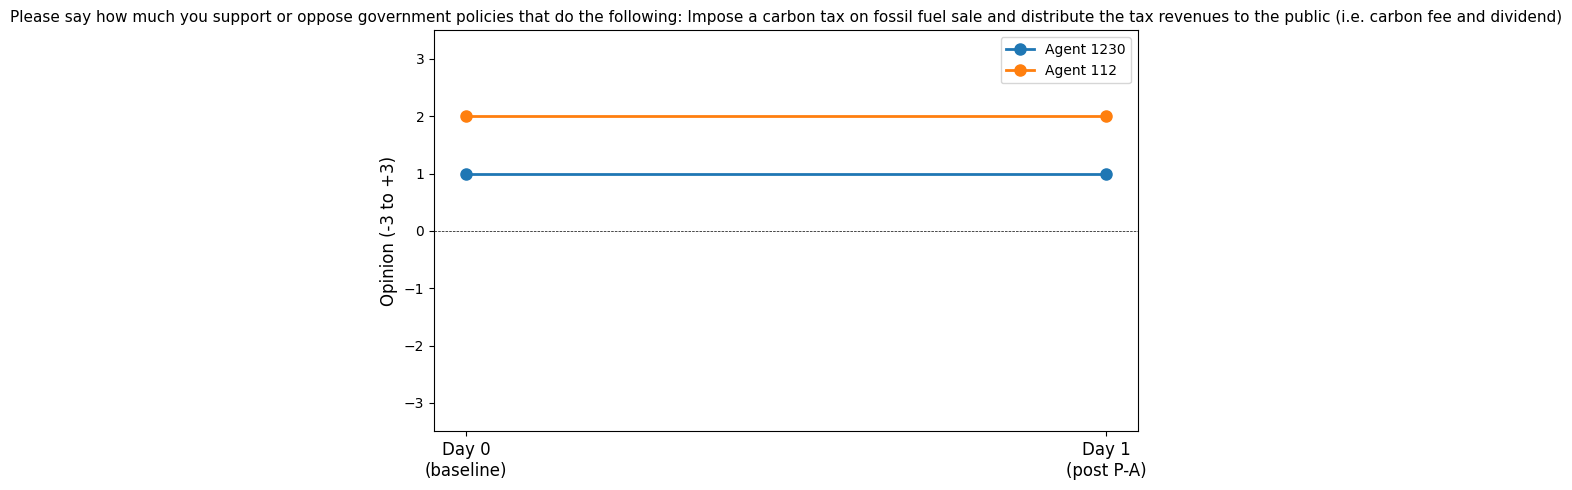

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for agent in agents:
    history = agent.opinion_history[target_policy]
    d0 = history[0][1]
    d1 = history[-1][1]
    ax.plot([0, 1], [d0, d1], marker="o", markersize=8, linewidth=2, label=f"Agent {int(agent.id)}")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Day 0\n(baseline)", "Day 1\n(post P-A)"], fontsize=12)
ax.set_ylabel("Opinion (-3 to +3)", fontsize=12)
ax.set_ylim(-3.5, 3.5)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_title(SURVEY_QUESTIONS[target_policy], fontsize=11)
ax.legend(fontsize=10, loc="best")
plt.tight_layout()
plt.show()

## 6. Opinion History Inspection

Verify `opinion_history` stores `(day, numeric)` tuples correctly across both survey rounds.

In [7]:
for agent in agents:
    history = agent.opinion_history.get(target_policy, [])
    print(f"Agent {int(agent.id)}: {history}")
    assert len(history) >= 2, f"Expected at least 2 entries, got {len(history)}"
    assert history[0][0] == 0, "First entry should be day 0"
    assert history[-1][0] == 1, "Last entry should be day 1"

print("\nAll agents have day 0 and day 1 entries.")

Agent 1230: [(0, 1), (1, 1)]
Agent 112: [(0, 2), (1, 2)]

All agents have day 0 and day 1 entries.


## 7. Shift Summary

In [8]:
print(f"Mean shift: {endofday_df['shift'].mean():+.2f}")
print(f"Agents shifted up (more supportive):   {(endofday_df['shift'] > 0).sum()}")
print(f"Agents shifted down (more opposed):    {(endofday_df['shift'] < 0).sum()}")
print(f"Agents unchanged:                      {(endofday_df['shift'] == 0).sum()}")
print()

# Shift distribution
print("Shift distribution:")
print(endofday_df["shift"].value_counts().sort_index().to_string())

Mean shift: +0.00
Agents shifted up (more supportive):   0
Agents shifted down (more opposed):    0
Agents unchanged:                      2

Shift distribution:
shift
0    2


## 8. DataFrame Output

The `run_end_of_day_survey` return value matches the Issue 8 spec (minus clamping columns).

In [9]:
print("DataFrame columns:", list(endofday_df.columns))
print(f"Shape: {endofday_df.shape}")
print()
endofday_df

DataFrame columns: ['agent_id', 'policy_id', 'day', 'raw_letter', 'raw_numeric', 'previous_numeric', 'shift']
Shape: (2, 7)



,agent_id,policy_id,day,raw_letter,raw_numeric,previous_numeric,shift
0,1230.0,ClimatePolicyID(5),1,E,1,1,0
1,112.0,ClimatePolicyID(5),1,F,2,2,0
